# VSD z036 — Contralateral-Leg Cleanup

**VSD.z036** is a full-body bilateral CT cropped to one knee (z-prefix VSD convention). The crop FOV
includes the **contralateral leg**, whose cortical bone is near-saturated (norm ≈ 1.0) and passes the
GT bone threshold (`GT_THRESH = 0.40`). This contaminates both the binary ground-truth volume and
the DRR projections used as model inputs.

**Contamination measured on stale predrr outputs (before cleanup):**

| Case | GT total | Main knee | Foreign bone | Min dist to knee |
|------|----------|-----------|-------------|------------------|
| z036 Left  | 677 k vox | 292,515 mm³ (90.6%) | **30,468 mm³ (9.4%)** | 1.1 mm |
| z036 Right | 726 k vox | 331,976 mm³ (95.8%) | **14,632 mm³ (4.2%)** | 1.1 mm |

## Why the shared pipeline cannot fix it

1. **`body_envelope_mask` keeps both legs** — the crop is one continuous soft-tissue envelope
   (CCs = 1 after opening at norm ≥ 0.10). There is no air gap between the knees in the cropped FOV,
   so the largest-soft-CC strategy does nothing.
2. **Bone-level distance gate is unsafe** — a 15 mm gate from the main bone CC flags **39/58**
   healthy cases because the fibula is also a small separate cluster near the tibia. We cannot
   distinguish foreign bone from fibula at the bone level alone.
3. **Erosion-based leg separation is fibula-safe** — eroding the soft-tissue mask by ~1 mm creates an
   air gap between the legs (but not between the tibia and fibula, which are enclosed in the same
   calf muscle). The component containing the most bone is the target leg (fibula included).
   Validated on z036 Right: foreign 0%, knee + fibula 100%. z036 Left is bridged even after 1 mm
   erosion (erosion keeps 97% of foreign bone) — it requires manual removal in 3D Slicer.

## Design
This is a **standalone notebook for z036 only** (analogous to `fractured_cast_cleanup.ipynb`).
It writes cleaned NIfTIs to `data/interim/healthy_cleaned/` and
`predrr_preprocessing.ipynb` re-points those two cases via a `CONTRALATERAL_CLEANED` override
(cell `castclean-override`). The shared pipeline is otherwise unchanged.

In [6]:
from pathlib import Path
import numpy as np
import SimpleITK as sitk
from scipy import ndimage
import matplotlib.pyplot as plt


def find_root(start: Path) -> Path:
    for cand in [start.resolve(), *start.resolve().parents]:
        if (cand / "data" / "interim").exists():
            return cand
    raise FileNotFoundError("could not find project root (expected data/interim)")


ROOT    = find_root(Path.cwd())
IN_DIR  = ROOT / "data" / "raw" / "healthy" / "VSD.z036"
OUT_DIR = ROOT / "data" / "interim" / "healthy_cleaned"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- parameters ----
SOFT_HU   = -300    # any voxel above this is 'soft tissue or bone' (≈ norm 0.10)
BONE_HU   =  150    # bone threshold for selecting the target-leg component (≈ norm 0.40 = GT_THRESH)
ERODE_MM  =  1.0    # erosion radius (mm) to break the inter-leg soft bridge
OPEN_ITER =  1      # opening iterations before erosion (removes small noise from soft mask)
REPORT_MIN_VOX = 50 # only list dropped components above this in the report

SIDES = ["Left", "Right"]

print("ROOT  :", ROOT)
print("input :", IN_DIR)
print("output:", OUT_DIR)
files = {side: IN_DIR / f"VSD_z036_{side}.nii.gz" for side in SIDES}
for side, f in files.items():
    print(f"  z036 {side}: {'OK' if f.exists() else 'MISSING'} — {f}")

ROOT  : C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject
input : C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\raw\healthy\VSD.z036
output: C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\interim\healthy_cleaned
  z036 Left: OK — C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\raw\healthy\VSD.z036\VSD_z036_Left.nii.gz
  z036 Right: OK — C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\raw\healthy\VSD.z036\VSD_z036_Right.nii.gz


## Erosion-based leg separation

`separate_target_leg` works entirely in native HU on the raw geometry so the cleaned NIfTI stays
byte-for-byte compatible with what `predrr_preprocessing.ipynb` expects as input.

**Algorithm:**
1. Build a soft-tissue mask (`HU > SOFT_HU`) and open it (`OPEN_ITER` iterations) to remove noise.
2. Erode `round(ERODE_MM / voxel_mm)` iterations — this pinches the soft bridge between legs
   without affecting the tibia-fibula gap (both bones sit inside the same muscle envelope).
3. Label connected components in the eroded soft mask.
4. Keep the component that contains the **most bone** (`HU > BONE_HU`) — this is the target knee
   with its fibula.
5. Dilate that component back by the same number of iterations to restore the soft boundary.
6. Apply `binary_fill_holes` to close any internal cavities from the erosion.
7. Zero out everything outside the keep-mask (set to `arr_hu.min()` = air).

Returns the cleaned array and a report of removed bone (vol mm³, max HU, min distance to kept bone)
so the removal is auditable — never silent. The caller checks the report to decide if auto-separation
succeeded or if manual work is needed.

In [7]:
def separate_target_leg(arr_hu, spacing_zyx, soft_hu=SOFT_HU, bone_hu=BONE_HU,
                        erode_mm=ERODE_MM, open_iter=OPEN_ITER):
    """Erosion-based contralateral-leg removal.

    Erodes the soft-tissue mask to break inter-leg bridges, then keeps the component
    with the most bone (fibula included — it is inside the same calf envelope).
    Returns (cleaned_arr, report) where report has keys:
      removed_bone_mm3, removed_max_hu, min_dist_mm_to_kept, foreign_pct_of_gt.
    A high foreign_pct (>5%) with small min_dist (<10 mm) means separation failed."""
    # spacing: use in-plane mean for isotropic-erosion proxy (raw scans are nearly isotropic)
    sp = np.array(spacing_zyx, dtype=float)
    erode_iters = max(1, round(erode_mm / float(sp.mean())))

    soft_mask = arr_hu > soft_hu
    struct = ndimage.generate_binary_structure(3, 1)  # 6-connectivity

    # open first to remove tiny disconnected noise
    if open_iter > 0:
        soft_mask = ndimage.binary_opening(soft_mask, structure=struct, iterations=open_iter)

    eroded = ndimage.binary_erosion(soft_mask, structure=struct, iterations=erode_iters)
    labeled, n_cc = ndimage.label(eroded)

    # pick the component that contains the most bone voxels
    bone_mask = arr_hu > bone_hu
    bone_per_cc = ndimage.sum(bone_mask, labeled, range(1, n_cc + 1))
    target_cc = int(np.argmax(bone_per_cc)) + 1
    target_eroded = labeled == target_cc

    # dilate back + fill holes
    target_dilated = ndimage.binary_dilation(target_eroded, structure=struct, iterations=erode_iters)
    keep_mask = ndimage.binary_fill_holes(target_dilated)

    # report: what bone was removed?
    removed_bone = bone_mask & ~keep_mask
    kept_bone    = bone_mask &  keep_mask
    vox_vol_mm3 = float(sp[0]) * float(sp[1]) * float(sp[2])
    removed_mm3  = float(removed_bone.sum()) * vox_vol_mm3
    kept_mm3     = float(kept_bone.sum()) * vox_vol_mm3
    foreign_pct  = 100.0 * removed_mm3 / max(removed_mm3 + kept_mm3, 1.0)

    min_dist_mm = float("inf")
    if removed_bone.any() and kept_bone.any():
        edt = ndimage.distance_transform_edt(~kept_bone, sampling=tuple(sp))
        min_dist_mm = float(edt[removed_bone].min())

    removed_max_hu = float(arr_hu[removed_bone].max()) if removed_bone.any() else 0.0

    report = dict(
        removed_bone_mm3 = round(removed_mm3),
        removed_max_hu   = round(removed_max_hu),
        min_dist_mm_to_kept = round(min_dist_mm, 1),
        foreign_pct_of_gt   = round(foreign_pct, 1),
        erode_iters = erode_iters,
        n_cc_after_erosion = n_cc,
    )

    cleaned = arr_hu.copy()
    cleaned[~keep_mask] = float(arr_hu.min())  # zero outside = air
    return cleaned, report


print("separate_target_leg() defined.")

separate_target_leg() defined.


## Process + QA — z036 Right (auto) and z036 Left (flagged)

For each leg: run `separate_target_leg`, print the report, and show **BEFORE / AFTER** MIPs
(axial / coronal / sagittal) overlaid with the bone mask so you can confirm the target knee and
fibula are intact and only the contralateral-leg bone was removed.

**Expected outcomes:**
- **z036 Right** — `foreign_pct` near 0%, `min_dist_mm` > 15 mm → auto-separation succeeded;
  save `VSD_z036_Right_clean.nii.gz`.
- **z036 Left** — `foreign_pct` remains high or `min_dist_mm` < 5 mm → erosion did not break the
  bridge; the notebook flags it and does **not** save a bogus auto result. Use the manual-ingest
  cell below after 3D Slicer work.


z036 Left
  Erosion iters    : 1 (ERODE_MM=1.0, mean sp=1.013 mm)
  CCs after erosion: 3
  Removed bone     : 6,836 mm3  (max HU 1513)
  Foreign % of GT  : 2.2%
  Min dist to knee : 0.5 mm


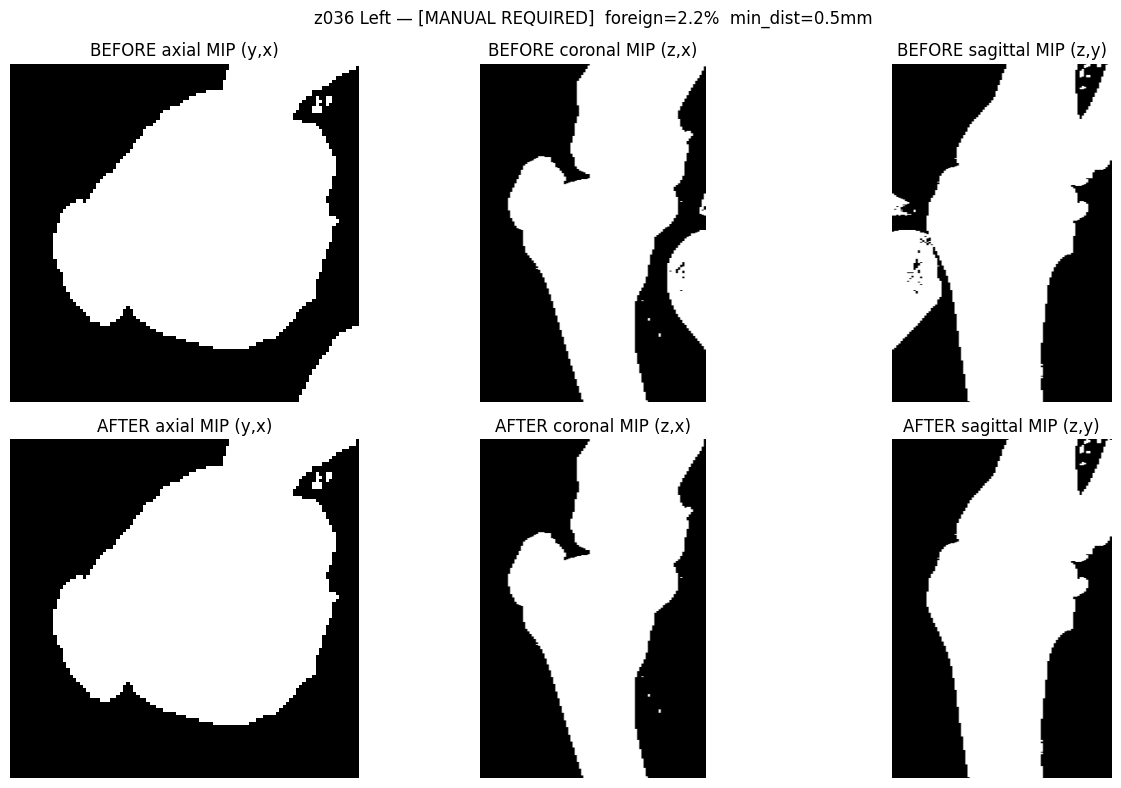

  [MANUAL REQUIRED] erosion did not fully separate the contralateral leg.
  Action: open data\raw\healthy\VSD.z036\VSD_z036_Left.nii.gz in 3D Slicer, manually delete the
          contralateral-leg bone (verify it is NOT the fibula), and save to:
          data/external/manual_contralateral_healthy/VSD_z036_Left.nrrd
  Then run the manual-ingest cell below.

z036 Right
  Erosion iters    : 1 (ERODE_MM=1.0, mean sp=1.013 mm)
  CCs after erosion: 3
  Removed bone     : 13,633 mm3  (max HU 1018)
  Foreign % of GT  : 4.1%
  Min dist to knee : 23.1 mm


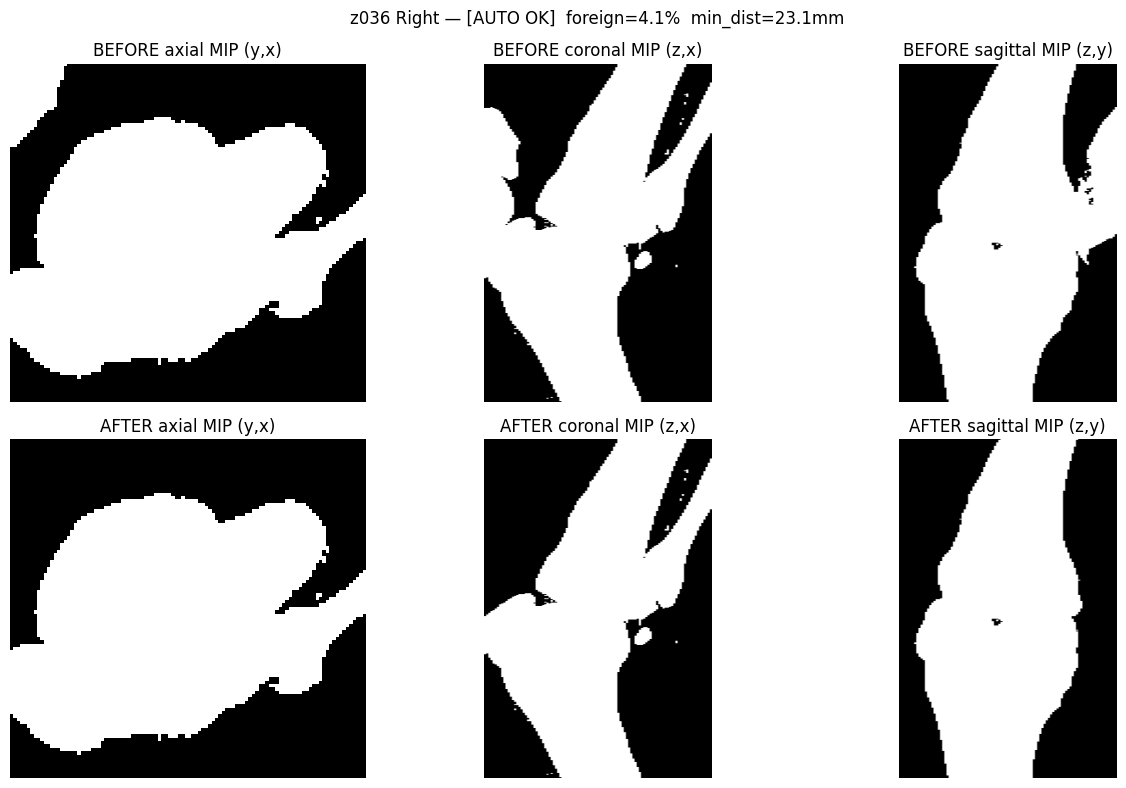

  [SAVED] -> data\interim\healthy_cleaned\VSD_z036_Right_clean.nii.gz


In [3]:
AUTO_SUCCESS_THRESHOLD_PCT  = 5.0   # foreign% below this => auto-separation successful
AUTO_SUCCESS_THRESHOLD_DIST = 5.0   # min dist (mm) above this also required

results = {}

for side in SIDES:
    fpath = files[side]
    print(f"\n{'='*60}")
    print(f"z036 {side}")
    img = sitk.ReadImage(str(fpath))
    arr = sitk.GetArrayFromImage(img).astype(np.float32)       # (z, y, x), HU
    sp_zyx = np.array(img.GetSpacing()[::-1], dtype=float)     # (z, y, x) mm

    cleaned, rep = separate_target_leg(arr, sp_zyx)

    print(f"  Erosion iters    : {rep['erode_iters']} (ERODE_MM={ERODE_MM}, mean sp={sp_zyx.mean():.3f} mm)")
    print(f"  CCs after erosion: {rep['n_cc_after_erosion']}")
    print(f"  Removed bone     : {rep['removed_bone_mm3']:,} mm3  (max HU {rep['removed_max_hu']})")
    print(f"  Foreign % of GT  : {rep['foreign_pct_of_gt']:.1f}%")
    print(f"  Min dist to knee : {rep['min_dist_mm_to_kept']:.1f} mm")

    auto_ok = (rep["foreign_pct_of_gt"] < AUTO_SUCCESS_THRESHOLD_PCT and
               rep["min_dist_mm_to_kept"] > AUTO_SUCCESS_THRESHOLD_DIST)

    # QA: BEFORE / AFTER bone-MIPs
    sz, sy, sx = sp_zyx
    fig, ax = plt.subplots(2, 3, figsize=(13, 8))
    for row, (vol, tag) in enumerate([(arr, "BEFORE"), (cleaned, "AFTER")]):
        bm = vol > BONE_HU
        ax[row, 0].imshow(bm.max(0), cmap="gray", origin="lower")
        ax[row, 0].set_title(f"{tag} axial MIP (y,x)")
        ax[row, 1].imshow(bm.max(1), cmap="gray", origin="lower", aspect=sz / sx)
        ax[row, 1].set_title(f"{tag} coronal MIP (z,x)")
        ax[row, 2].imshow(bm.max(2), cmap="gray", origin="lower", aspect=sz / sy)
        ax[row, 2].set_title(f"{tag} sagittal MIP (z,y)")
    for a in ax.ravel():
        a.axis("off")
    status = "AUTO OK" if auto_ok else "MANUAL REQUIRED"
    plt.suptitle(f"z036 {side} — [{status}]  foreign={rep['foreign_pct_of_gt']:.1f}%  min_dist={rep['min_dist_mm_to_kept']:.1f}mm")
    plt.tight_layout()
    plt.show()

    results[side] = dict(arr=arr, cleaned=cleaned, img=img, report=rep, auto_ok=auto_ok)

    if auto_ok:
        out_path = OUT_DIR / f"VSD_z036_{side}_clean.nii.gz"
        out_img = sitk.GetImageFromArray(cleaned)
        out_img.CopyInformation(img)
        sitk.WriteImage(out_img, str(out_path))
        print(f"  [SAVED] -> {out_path.relative_to(ROOT)}")
    else:
        print(f"  [MANUAL REQUIRED] erosion did not fully separate the contralateral leg.")
        print(f"  Action: open {fpath.relative_to(ROOT)} in 3D Slicer, manually delete the")
        print(f"          contralateral-leg bone (verify it is NOT the fibula), and save to:")
        print(f"          data/external/manual_contralateral_healthy/VSD_z036_{side}.nrrd")
        print(f"  Then run the manual-ingest cell below.")

## Manual ingest — z036 Left

**Prerequisites (do before running this cell):**
1. Open `data/raw/healthy/VSD.z036/VSD_z036_Left.nii.gz` in 3D Slicer.
2. Confirm visually that the dense corner structure is the **contralateral leg** (not the fibula —
   the fibula runs parallel and close to the tibia, not in a separate corner of the FOV).
3. Using the **Segment Editor** → *Scissors* or *Erase* tool, delete the contralateral-leg bone
   from the volume (work in the HU data directly, not a separate segmentation layer, so the geometry
   is preserved).
4. Export the result as a volume to:
   `data/external/manual_contralateral_healthy/VSD_z036_Left.nrrd`
   (create the folder if needed).

This cell loads that `.nrrd`, applies the same residual-speck cleanup used in
`fractured_cast_cleanup.ipynb`, and saves `VSD_z036_Left_clean.nii.gz`.

Speck cleanup: removed 99 voxels across 0 reported component(s):


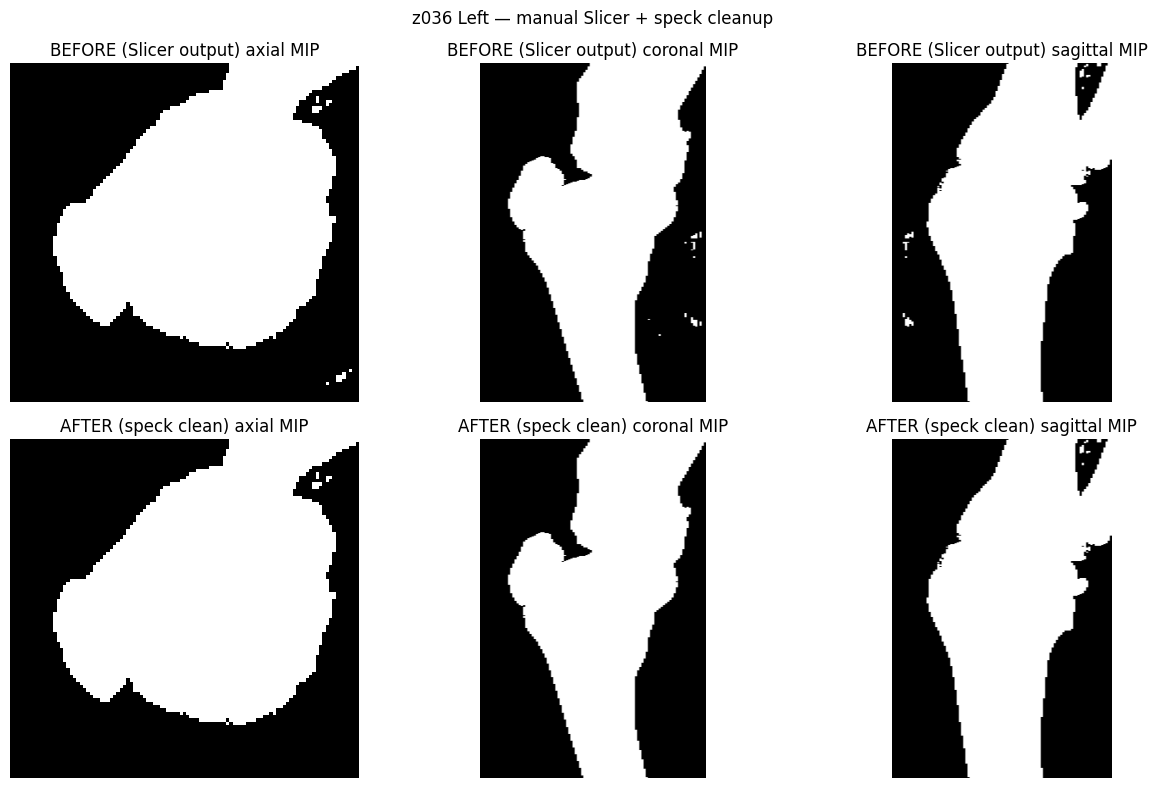

[SAVED] -> data\interim\healthy_cleaned\VSD_z036_Left_clean.nii.gz


In [9]:
MANUAL_DIR  = ROOT / "data" / "external" / "manual_contralateral_healthy"
MANUAL_FILE = MANUAL_DIR / "VSD_z036_Left_manual.nrrd"

if not MANUAL_FILE.exists():
    print(f"[SKIP] Manual segmentation not found yet: {MANUAL_FILE}")
    print("       Complete the 3D Slicer step described in the cell above first.")
else:
    img_m = sitk.ReadImage(str(MANUAL_FILE))
    arr_m = sitk.GetArrayFromImage(img_m).astype(np.float32)      # (z, y, x), HU
    sp_zyx_m = np.array(img_m.GetSpacing()[::-1], dtype=float)

    # Residual-speck cleanup (same logic as fractured_cast_cleanup.ipynb clean_specks)
    CLEAN_BONE_HU  = 200
    CLEAN_KEEP_MM  = 15.0
    CLEAN_RESCUE_HU  = 800
    CLEAN_RESCUE_VOX = 500

    occ = arr_m > CLEAN_BONE_HU
    lbl, n = ndimage.label(occ)
    sizes = ndimage.sum(np.ones_like(lbl), lbl, range(1, n + 1))
    main = int(np.argmax(sizes)) + 1
    edt  = ndimage.distance_transform_edt(lbl != main, sampling=tuple(sp_zyx_m))
    drop = np.zeros_like(occ)
    report_m = []
    for i in range(1, n + 1):
        if i == main:
            continue
        comp = lbl == i
        d   = float(edt[comp].min())
        sz  = int(sizes[i - 1])
        hu  = float(arr_m[comp].max())
        keep = (d <= CLEAN_KEEP_MM) or (hu >= CLEAN_RESCUE_HU and sz >= CLEAN_RESCUE_VOX)
        if not keep:
            drop |= comp
            if sz >= 50:
                report_m.append(dict(size=sz, dist_mm=round(d, 1), hu_max=round(hu)))
    cleaned_m = arr_m.copy()
    cleaned_m[drop] = float(arr_m.min())

    n_drop = int(((arr_m > CLEAN_BONE_HU) & ~(cleaned_m > CLEAN_BONE_HU)).sum())
    print(f"Speck cleanup: removed {n_drop} voxels across {len(report_m)} reported component(s):")
    for r in report_m:
        print(f"  size={r['size']:<6d} dist={r['dist_mm']:5.1f} mm  HUmax={r['hu_max']}")

    # QA: BEFORE / AFTER
    sz_sp, sy_sp, sx_sp = sp_zyx_m
    fig, ax = plt.subplots(2, 3, figsize=(13, 8))
    for row, (vol, tag) in enumerate([(arr_m, "BEFORE (Slicer output)"), (cleaned_m, "AFTER (speck clean)")]):
        bm = vol > CLEAN_BONE_HU
        ax[row, 0].imshow(bm.max(0), cmap="gray", origin="lower")
        ax[row, 0].set_title(f"{tag} axial MIP")
        ax[row, 1].imshow(bm.max(1), cmap="gray", origin="lower", aspect=sz_sp / sx_sp)
        ax[row, 1].set_title(f"{tag} coronal MIP")
        ax[row, 2].imshow(bm.max(2), cmap="gray", origin="lower", aspect=sz_sp / sy_sp)
        ax[row, 2].set_title(f"{tag} sagittal MIP")
    for a in ax.ravel():
        a.axis("off")
    plt.suptitle("z036 Left — manual Slicer + speck cleanup")
    plt.tight_layout()
    plt.show()

    out_path = OUT_DIR / "VSD_z036_Left_clean.nii.gz"
    out_img = sitk.GetImageFromArray(cleaned_m)
    out_img.CopyInformation(img_m)
    sitk.WriteImage(out_img, str(out_path))
    print(f"[SAVED] -> {out_path.relative_to(ROOT)}")

## Next steps

1. **Review** BEFORE/AFTER MIPs above: the AFTER panels must show the same knee anatomy (femur,
   tibia, fibula, patella) as BEFORE, with only the far-corner contralateral bone absent. If the
   fibula was accidentally removed, decrease `ERODE_MM` and re-run.
2. **Feed into `predrr_preprocessing.ipynb`**: the `CONTRALATERAL_CLEANED` override block in cell
   `castclean-override` re-points `VSD_z036_Right` (and `VSD_z036_Left` once its file exists) at
   `data/interim/healthy_cleaned/<file>_clean.nii.gz`. Re-run cell 5 and confirm the log prints
   `[CONTRALATERAL-CLEANED] VSD_z036_Right -> ...`.
3. **Regenerate predrr** for z036 (re-run the batch cell), then DRRs, then clear the
   `predrr_occupancy_*` cache before retraining on HPC.
4. **z036 Left** — run the manual-ingest cell above once `data/external/manual_contralateral_healthy/
   VSD_z036_Left.nrrd` exists. Until then, `VSD_z036_Left` in the predrr override warns and falls
   back to the raw NIfTI (safe no-op — it just won't be cleaned yet).